## Data Ingestion & Transformation

In [36]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [37]:
# Reading the CSV file after uploading it
df_raw = pd.read_csv("/content/drive/MyDrive/creditcard.csv")
df_raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [73]:
# Checking count of null values and data-types
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [39]:
# Observing  the 'time' and 'amount' columns
df_raw[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


The max value in 'time' is 172792.00 which is unusual as the the unit is 'seconds' and the column contains the running total of the time

In [40]:
# Converting time unit to 'hour' from 'seconds' and segmenting the count of transactions by each hour
df = df_raw.copy()
df["Hour"] = (df['Time']//3600)%24
df['Hour'].value_counts().sort_index().head(5)


,count
Hour,
0.0,7695
1.0,4220
2.0,3328
3.0,3492
4.0,2209


In [41]:
# Using log1p to transform the transaction amount
df['Log_Amount'] = np.log1p(df['Amount'])

print(f"Original Max Amount: {df['Amount'].max()}")
print(f"Log Max Amount: {df['Log_Amount'].max():.2f}")

Original Max Amount: 25691.16
Log Max Amount: 10.15


In [42]:
# Dropping the original 'Time' & 'Amount' columns after transformation
df = df.drop(columns = ['Time', 'Amount'])

In [48]:
# Rescale hour and log_amount columns to match PCA characteristics (Mean=0, Std=1)

scaler = StandardScaler()
df[['Hour', 'Log_Amount']] = scaler.fit_transform(df[['Hour', 'Log_Amount']])

# Viewing final transformed results
df[['Hour', 'Log_Amount', 'V1', 'V2', 'Class']].head()

,Hour,Log_Amount,V1,V2,Class
0,-2.40693,1.124303,-1.359807,-0.072781,0
1,-2.40693,-1.114639,1.191857,0.266151,0
2,-2.40693,1.682368,-1.358354,-1.340163,0
3,-2.40693,1.009339,-0.966272,-0.185226,0
4,-2.40693,0.670241,-1.158233,0.877737,0


## Exploratory Data Analysis

Top 5 signals are: ['V3', 'V14', 'V17', 'V12', 'V10']


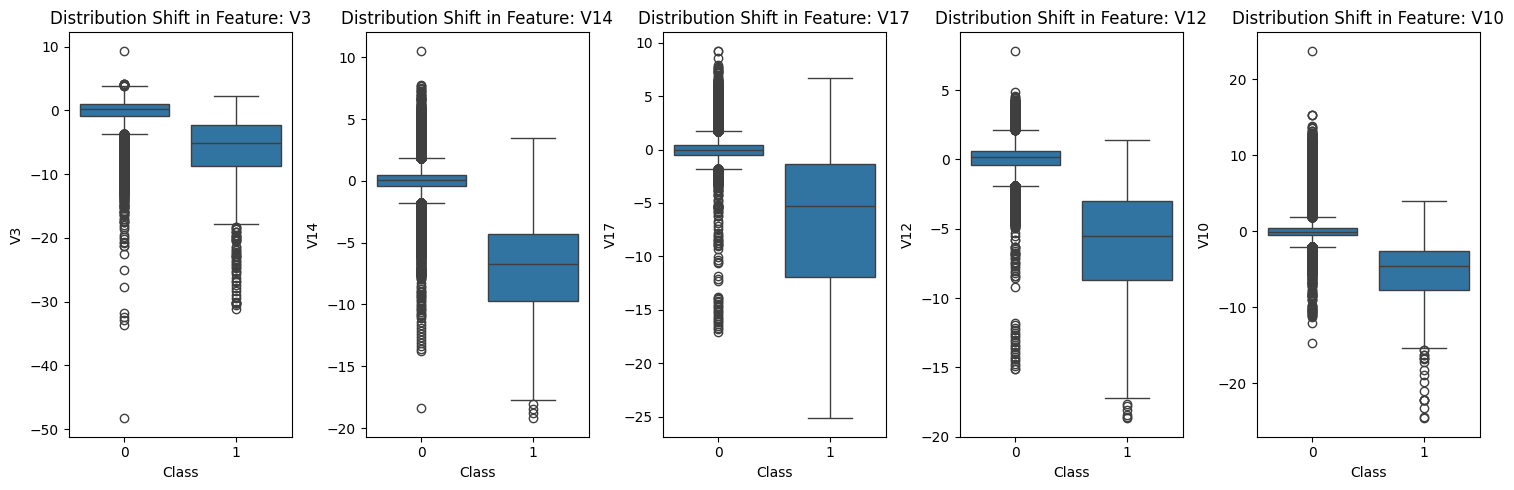

In [49]:
# Calculating mean and difference of fraud vs legitimate in all 'V' columns
v_cols = [f'V{i}' for i in range(1, 29)]
mean_diff = df.groupby('Class')[v_cols].mean().T
mean_diff['abs_diff'] = np.abs(mean_diff[1] - mean_diff[0])

# Sorting the result by highest mean_diff to get the highest variance
top_signals = mean_diff.sort_values('abs_diff', ascending=False).index.tolist()
print(f"Top 5 signals are: {top_signals[:5]}")

# Plotting distributions of the top highest features
flag, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, col in enumerate(top_signals[:5]):
  sns.boxplot(x='Class', y=col, data=df, ax=axes[i])
  axes[i].set_title(f"Distribution Shift in Feature: {col}")
plt.tight_layout()
plt.show()

In [45]:
# Importing required libraries and fitting the data into the model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Define x and y (features and target)
x = df.drop(columns = ['Class'])
y = df['Class']

# Split the data into training using stratify to divide the data with same proportion and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify=y, random_state = 25)

# Checking the train and test size after splitting the data
print(f"Training test size: {x_train.shape[0]} rows | Fraud cases: {y_train.sum()}")
print(f"Testing test size: {x_test.shape[0]} rows | Fraud cases: {y_test.sum()}")

Training test size: 199364 rows | Fraud cases: 344
Testing test size: 85443 rows | Fraud cases: 148


## Data Modelling using Scikit-learn and Random Forest

In [46]:
# Initializing randomforest with balanced class weight and training the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=20,
    random_state=25,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)
print("Model training successfully completed!")

Model training successfully completed!


-----MODEL OPERATIONAL PERFORMANCE-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.95      0.75      0.84       148

    accuracy                           1.00     85443
   macro avg       0.97      0.87      0.92     85443
weighted avg       1.00      1.00      1.00     85443



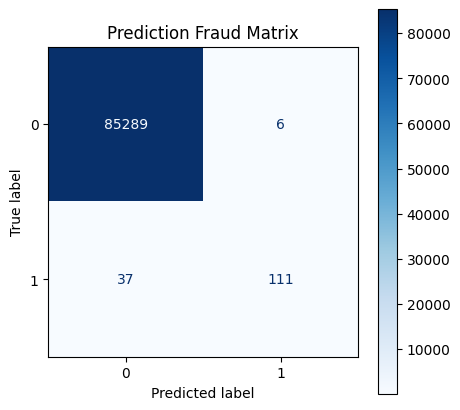

In [50]:
# Making predictions on the test data
y_pred = rf_model.predict(x_test)

# Prinitng traditional metrics
print("-----MODEL OPERATIONAL PERFORMANCE-----")
print(classification_report(y_test, y_pred))

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, values_format='d', cmap='Blues')
plt.title("Prediction Fraud Matrix")
plt.show()

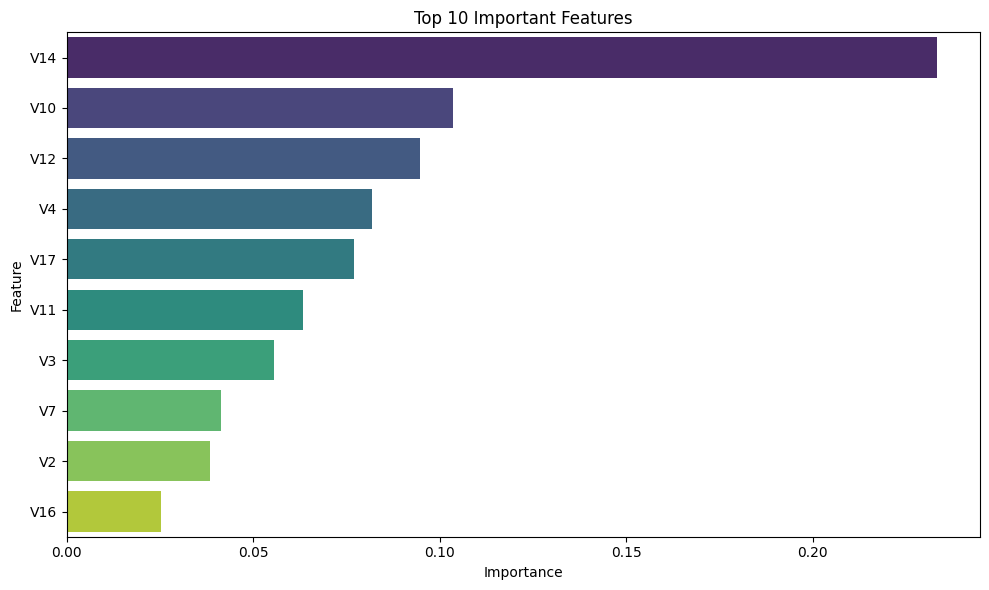

In [60]:
# Extracting feature importance rankings
importances = rf_model.feature_importances_
features = x.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the top 10 important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis', hue='Feature')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()


PR-AUC Score: 0.8591


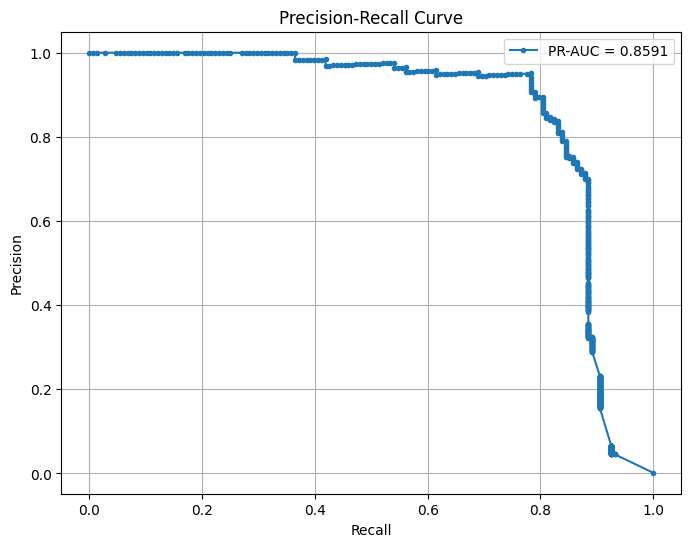

In [63]:
from sklearn.metrics import precision_recall_curve, auc

# Get the probability scores for the fraud class (Class 1)
y_prob = rf_model.predict_proba(x_test)[:, 1]

# Calculate Precision and Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate PR-AUC
pr_auc = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc:.4f}")

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

PR-AUC is well over 0.85 which means the model is doing an excellent job of ranking fraudulent transactions higher than legitimate ones, without generating an overwhelming number of false positives.